# 실습 3-1 : Random Forest

#### **<실습 내용>**

1. 실습 데이터 탐색 및 전처리
- 분류 데이터 (MachineFailure)
- 회귀 데이터 (Concrete)

2. Random Forest Classifier
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

3. Random Forest Regressor
- 모델 학습 및 성능 평가
- 변수 중요도 시각화

4. 하이퍼 파라미터 최적화
- GridSearchCV를 활용한 최적 파라미터 탐색

## 분석 준비

### 주요 라이브러리 호출

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def setup_korean_font():
    """matplotlib/seaborn 한글 폰트 적용. sns.set_theme() 호출 후 재호출 필요."""
    _korean_fonts = ["Malgun Gothic", "NanumGothic", "AppleGothic", "Gulim"]
    _available = {f.name for f in fm.fontManager.ttflist}
    for _font in _korean_fonts:
        if _font in _available:
            plt.rcParams["font.family"] = _font
            break
    plt.rcParams["axes.unicode_minus"] = False


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
setup_korean_font()

---

## 1) 분류 문제

In [2]:
MF_Data = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_cls_data.csv"))
MF_Data.head()

,Temperature,Humidity,Operator,Measure1,Measure2,Measure3,Measure4,Measure5,Measure6,Measure7,Measure8,Measure9,Measure10,Measure11,Measure12,Measure13,Measure14,Measure15,Hours Since Previous Failure,Failure
0,67,82,Operator1,291,1,1,1041,846,334,706,1086,256,1295,766,968,1185,1355,1842,90,No
1,68,77,Operator1,1180,1,1,1915,1194,637,1093,524,919,245,403,723,1446,719,748,91,No
2,64,76,Operator1,1406,1,1,511,1577,1121,1948,1882,1301,273,1927,1123,717,1518,1689,92,No
3,63,80,Operator1,550,1,1,1754,1834,1413,1151,945,1312,1494,1755,1434,502,1336,711,93,No
4,65,81,Operator1,1928,1,2,1326,1082,233,1441,1736,1033,1549,802,1819,1616,1507,507,94,No


In [3]:
print("데이터 크기 :", MF_Data.shape)
print("출력변수 분포:")
print(MF_Data["Failure"].value_counts())

데이터 크기 : (7900, 20)
출력변수 분포:
Failure
No     7825
Yes      75
Name: count, dtype: int64


In [23]:
# 입출력 변수 분할
Y_cls = MF_Data["Failure"]
X_cls = MF_Data.drop(["Failure"], axis=1)

# 범주형 변수 처리
X_cls["Measure2"] = X_cls["Measure2"].astype("category")
X_cls["Measure3"] = X_cls["Measure3"].astype("category")
X_cls = pd.get_dummies(X_cls)
cls_columns = X_cls.columns

# 출력변수 인코딩 (sklearn 1.7+ 는 정수형 레이블 필요)
Y_cls = Y_cls.replace({"No": 0, "Yes": 1}).astype(int)

# 데이터 분할
X_train_cls, X_test_cls, Y_train_cls, Y_test_cls = train_test_split(
    X_cls, Y_cls, test_size=0.3, random_state=0, stratify=Y_cls)

print("학습 데이터 :", X_train_cls.shape)
print("테스트 데이터 :", X_test_cls.shape)

학습 데이터 : (5530, 31)
테스트 데이터 : (2370, 31)


C:\Users\Admin\AppData\Local\Temp\ipykernel_39480\2601454091.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Y_cls = Y_cls.replace({"No": 0, "Yes": 1}).astype(int)


In [5]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print()
    print("혼동행렬")
    print(confusion_matrix(real, pred))

---

### 1-1) Random Forest Classifier 모델 학습 및 성능 평가

> **Random Forest**는 Bagging의 일종으로, 붓스트랩 샘플링 + 무작위 변수 선택을 통해 다수의 의사결정나무를 생성하고 결합하는 앙상블 모델임
> - **붓스트랩 샘플링**: 학습 데이터에서 복원 추출로 여러 표본을 만들어 베이스 모델의 다양성을 확보함
> - **무작위 변수 선택**: 각 노드마다 입력변수의 일부만 랜덤 선택하여 트리 간 상관성을 줄임
> - 분류: 다수결 투표, 회귀: 평균으로 최종 예측을 수행함

In [6]:
RF_cls = RandomForestClassifier()
RF_cls.fit(X_train_cls, Y_train_cls)
RF_cls_pred = RF_cls.predict(X_test_cls)
get_classscore(Y_test_cls, RF_cls_pred)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.682
F1-score  : 0.811

혼동행렬
[[2348    0]
 [   7   15]]


### 1-2) 변수 중요도 시각화

> Random Forest는 **Mean Decrease in Impurity** 방식으로 변수 중요도를 산출함

> 각 트리에서 특정 변수가 노드 분할에 사용될 때의 불순도 감소량을 평균내어 중요도를 계산함

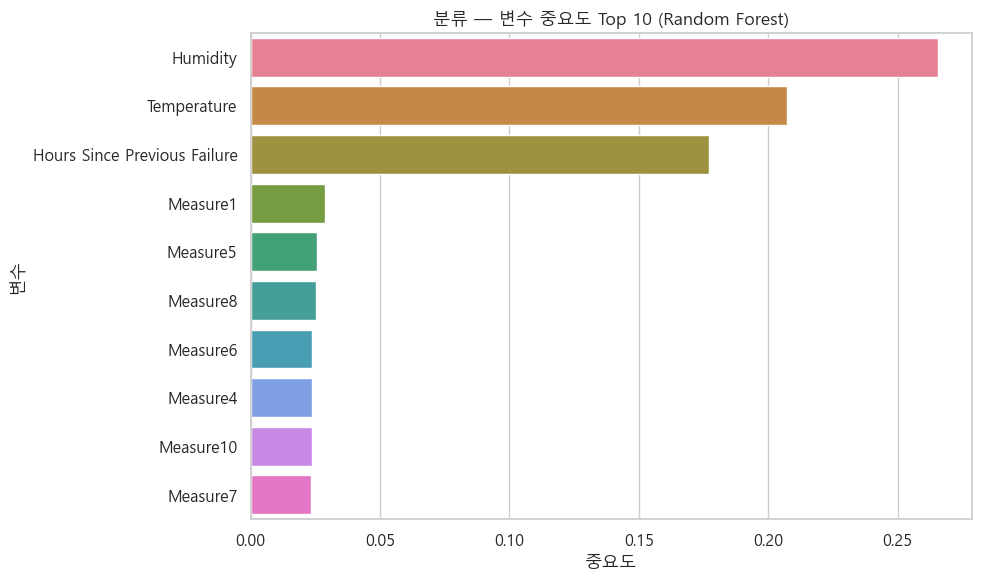

In [7]:
# 변수 중요도 추출 및 시각화
setup_korean_font()
var_imp = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_top10 = var_imp.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", data=imp_top10, hue="Variable", legend=False)
plt.title("분류 — 변수 중요도 Top 10 (Random Forest)")
plt.xlabel("중요도")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

### 1-3) 모델 성능 개선

> Random Forest의 주요 하이퍼 파라미터:
>
> | 파라미터 | 의미 |
> |:---:|:---:|
> | n_estimators | 베이스 모델(의사결정나무)의 수 |
> | max_depth | 개별 트리의 최대 깊이 |
> | max_features | 각 노드에서 랜덤 선택하는 변수 수 (분류: sqrt, 회귀: n/3) |
> | min_samples_leaf | 끝 노드의 최소 샘플 수 |
> | min_samples_split | 노드 분할을 위한 최소 샘플 수 |

In [8]:
params = {
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [2, 4, 8],
    "n_estimators": [100, 300],
    "max_features": ["sqrt", 3]
}

grid_cls = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params, cv=5, scoring="f1", n_jobs=-1
)
grid_cls.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls.best_params_)
print("최적 F1-score: %.4f" % grid_cls.best_score_)

최적 파라미터: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
최적 F1-score: 0.8058


In [9]:
# 최적 모델로 테스트 성능 평가
best_pred_cls = grid_cls.predict(X_test_cls)
get_classscore(Y_test_cls, best_pred_cls)

Accuracy  : 0.997
Precision : 1.000
Recall    : 0.727
F1-score  : 0.842

혼동행렬
[[2348    0]
 [   6   16]]


---

## 2) 회귀 문제

In [10]:
Concrete = pd.read_csv(os.path.join(os.getcwd(), "dataset", "day3-1_reg_data.csv"))

Y_reg = Concrete["Concrete_compressive_strength"]
X_reg = Concrete.drop(["Concrete_compressive_strength"], axis=1)

X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=0)

print("학습 데이터 :", X_train_reg.shape)
print("테스트 데이터 :", X_test_reg.shape)

학습 데이터 : (721, 8)
테스트 데이터 : (309, 8)


In [11]:
# 회귀 성능 평가 함수
def get_regscore(true, pred):
    print("MSE       : %.3f" % mean_squared_error(true, pred))
    print("RMSE      : %.3f" % np.sqrt(mean_squared_error(true, pred)))
    print("MAE       : %.3f" % mean_absolute_error(true, pred))
    print("R-squared : %.3f" % r2_score(true, pred))

### 2-1) Random Forest Regressor 모델 학습 및 성능 평가

In [12]:
RF_reg = RandomForestRegressor()
RF_reg.fit(X_train_reg, Y_train_reg)
RF_reg_pred = RF_reg.predict(X_test_reg)
get_regscore(Y_test_reg, RF_reg_pred)

MSE       : 26.492
RMSE      : 5.147
MAE       : 3.598
R-squared : 0.897


### 2-2) 변수 중요도 시각화

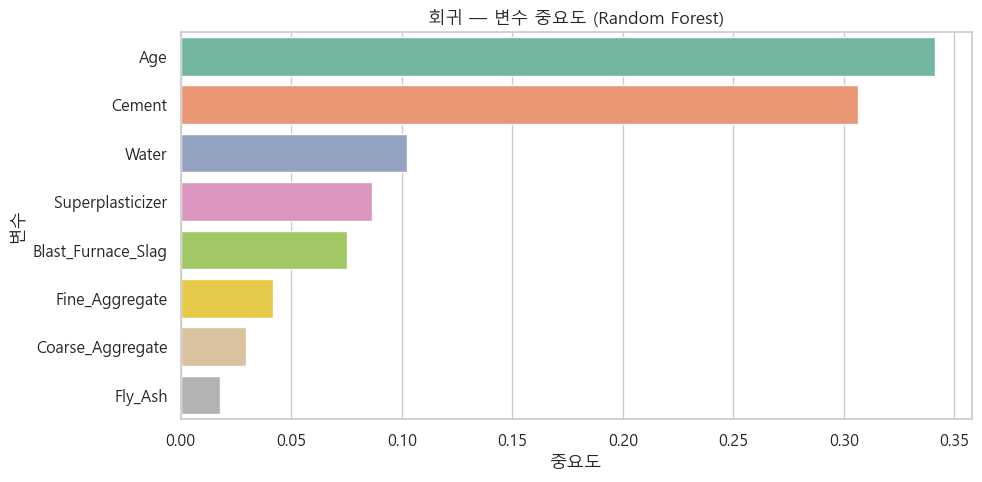

In [13]:
setup_korean_font()
var_imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
var_imp_reg = var_imp_reg.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x="Importance", y="Variable", data=var_imp_reg, hue="Variable", legend=False)
plt.title("회귀 — 변수 중요도 (Random Forest)")
plt.xlabel("중요도")
plt.ylabel("변수")
plt.tight_layout()
plt.show()

### 2-3) 예측 시각화

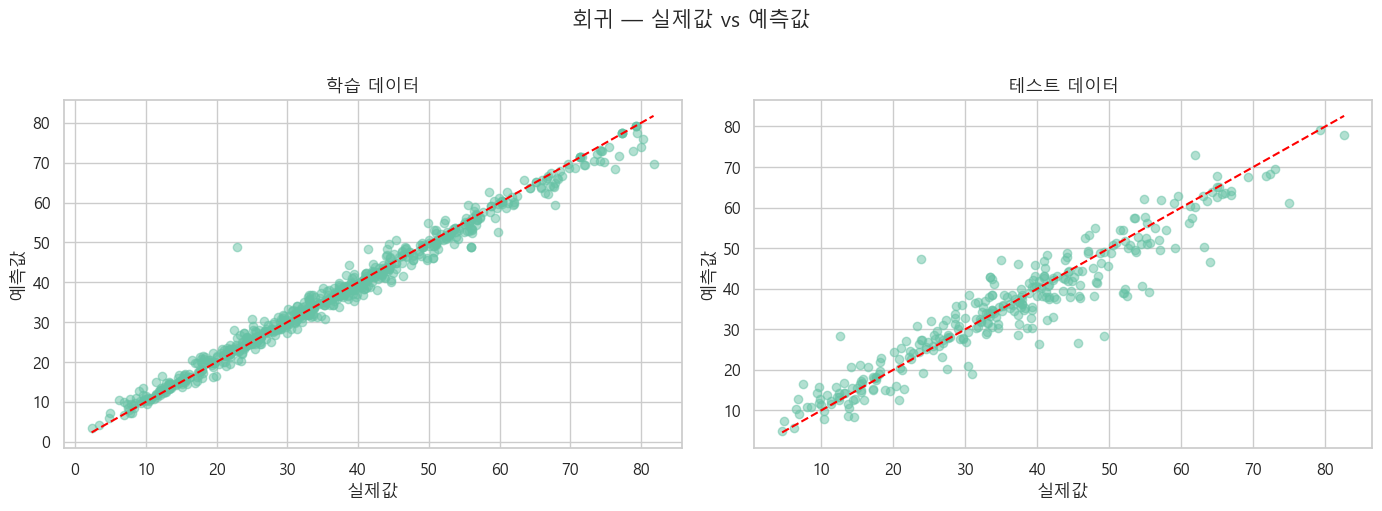

In [14]:
setup_korean_font()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_train_reg, RF_reg.predict(X_train_reg), alpha=0.5)
axes[0].plot([Y_train_reg.min(), Y_train_reg.max()], [Y_train_reg.min(), Y_train_reg.max()], "r--")
axes[0].set_xlabel("실제값")
axes[0].set_ylabel("예측값")
axes[0].set_title("학습 데이터")

axes[1].scatter(Y_test_reg, RF_reg_pred, alpha=0.5)
axes[1].plot([Y_test_reg.min(), Y_test_reg.max()], [Y_test_reg.min(), Y_test_reg.max()], "r--")
axes[1].set_xlabel("실제값")
axes[1].set_ylabel("예측값")
axes[1].set_title("테스트 데이터")

plt.suptitle("회귀 — 실제값 vs 예측값", y=1.02)
plt.tight_layout()
plt.show()

### 2-4) 모델 성능 개선

In [15]:
params_reg = {
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [2, 4],
    "n_estimators": [100, 300]
}

grid_reg = GridSearchCV(
    RandomForestRegressor(random_state=0),
    param_grid=params_reg, cv=5, scoring="r2", n_jobs=-1
)
grid_reg.fit(X_train_reg, Y_train_reg)

print("최적 파라미터:", grid_reg.best_params_)
print("최적 R-squared: %.4f" % grid_reg.best_score_)

최적 파라미터: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 300}
최적 R-squared: 0.8902


In [16]:
# 최적 모델로 테스트 성능 평가
best_pred_reg = grid_reg.predict(X_test_reg)
get_regscore(Y_test_reg, best_pred_reg)

MSE       : 28.243
RMSE      : 5.314
MAE       : 3.787
R-squared : 0.890


---

## 5) Vibe Coding 실습

**[과제 1]**
지수는 Random Forest가 계산한 변수 중요도(Feature Importance)가 정말 중요한 변수를 의미하는지 궁금해졌습니다. AI와 상의하여 변수 중요도를 확인하고, 중요도가 높은 상위 변수만 사용했을 때와 전체 변수를 사용했을 때의 성능을 비교해 보세요. 결과를 바탕으로 "중요한 변수만 사용하면 항상 좋은 모델이 될까?"에 대해 자신의 의견을 정리해 보세요.

[분류] 성능 비교
    모델  F1-score
 전체 변수    0.8108
 상위 5개    0.8500
상위 10개    0.8500
상위 15개    0.8421

[회귀] 성능 비교
   모델  R-squared
전체 변수     0.8968
상위 3개     0.8402
상위 5개     0.9002
상위 7개     0.8956


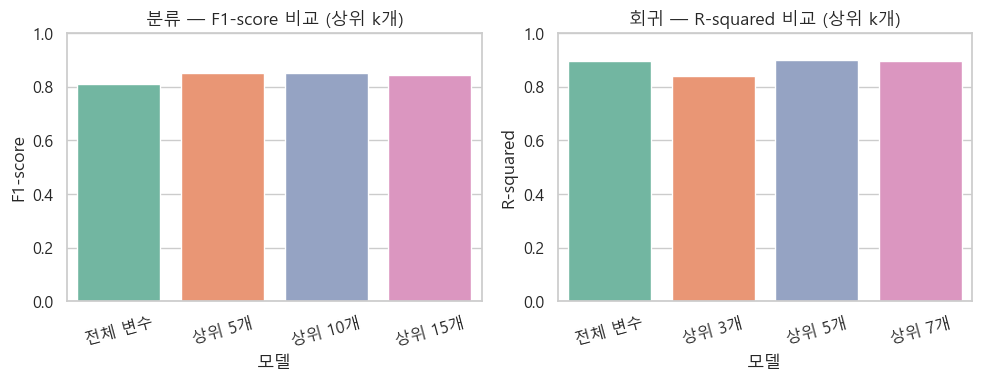


[소견]
- Feature Importance는 '모델 내부에서 분할에 기여한 정도'이지, 변수 간 상호작용·다중공선성을 완전히 반영하지는 않습니다.
- k를 줄이면 노이즈 변수를 제거해 성능이 오를 수도 있지만, k가 너무 작으면 유용한 변수까지 빠져 성능이 떨어질 수 있습니다.
- 분류·회귀 모두 '전체 변수' 대비 특정 k에서만 개선되거나, k에 따라 성능이 달라지므로
  '중요한 변수만 사용하면 항상 좋은 모델'이라고 보기 어렵습니다.
  → 실무에서는 여러 k 값을 비교해 성능·해석력·비용의 균형점을 찾는 것이 적절합니다.


In [29]:
# [과제 1] 변수 중요도 상위 변수만 사용 vs 전체 변수 — 성능 비교
setup_korean_font()

TOP_K_CLS = [5, 10, 15]
TOP_K_REG = [3, 5, 7]

# --- 분류: 상위 k개 변수별 성능 ---
imp_cls = pd.DataFrame({"Variable": cls_columns, "Importance": RF_cls.feature_importances_})
imp_cls_sorted = imp_cls.sort_values("Importance", ascending=False)

cls_rows = [{
    "모델": "전체 변수",
    "F1-score": f1_score(Y_test_cls, RF_cls.predict(X_test_cls)),
}]
for k in TOP_K_CLS:
    top_vars = imp_cls_sorted.head(k)["Variable"]
    rf_top = RandomForestClassifier(random_state=0)
    rf_top.fit(X_train_cls[top_vars], Y_train_cls)
    cls_rows.append({
        "모델": f"상위 {k}개",
        "F1-score": f1_score(Y_test_cls, rf_top.predict(X_test_cls[top_vars])),
    })

cls_compare = pd.DataFrame(cls_rows)
print("[분류] 성능 비교")
print(cls_compare.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# --- 회귀: 상위 k개 변수별 성능 ---
imp_reg = pd.DataFrame({"Variable": X_train_reg.columns, "Importance": RF_reg.feature_importances_})
imp_reg_sorted = imp_reg.sort_values("Importance", ascending=False)

reg_rows = [{
    "모델": "전체 변수",
    "R-squared": r2_score(Y_test_reg, RF_reg.predict(X_test_reg)),
}]
for k in TOP_K_REG:
    top_vars = imp_reg_sorted.head(k)["Variable"]
    rf_top = RandomForestRegressor(random_state=0)
    rf_top.fit(X_train_reg[top_vars], Y_train_reg)
    reg_rows.append({
        "모델": f"상위 {k}개",
        "R-squared": r2_score(Y_test_reg, rf_top.predict(X_test_reg[top_vars])),
    })

reg_compare = pd.DataFrame(reg_rows)
print("\n[회귀] 성능 비교")
print(reg_compare.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# --- 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(data=cls_compare, x="모델", y="F1-score", hue="모델", ax=axes[0], legend=False)
axes[0].set_title("분류 — F1-score 비교 (상위 k개)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(data=reg_compare, x="모델", y="R-squared", hue="모델", ax=axes[1], legend=False)
axes[1].set_title("회귀 — R-squared 비교 (상위 k개)")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print("\n[소견]")
print("- Feature Importance는 '모델 내부에서 분할에 기여한 정도'이지, 변수 간 상호작용·다중공선성을 완전히 반영하지는 않습니다.")
print("- k를 줄이면 노이즈 변수를 제거해 성능이 오를 수도 있지만, k가 너무 작으면 유용한 변수까지 빠져 성능이 떨어질 수 있습니다.")
print("- 분류·회귀 모두 '전체 변수' 대비 특정 k에서만 개선되거나, k에 따라 성능이 달라지므로")
print("  '중요한 변수만 사용하면 항상 좋은 모델'이라고 보기 어렵습니다.")
print("  → 실무에서는 여러 k 값을 비교해 성능·해석력·비용의 균형점을 찾는 것이 적절합니다.")

**[과제 2]** 지수는 Random Forest가 단일 의사결정나무보다 항상 더 좋은 성능을 보이는지 궁금해졌습니다. 동일한 데이터로 단일 의사결정나무 모델을 학습시켜 이번 실습의 Random Forest 모델과 성능을 비교해 보세요. 그리고 그 차이가 나타나는 이유를 AI와 상의하여 해석해 보세요.

[분류] 모델 비교
           모델  Accuracy  F1-score
Random Forest    0.9970    0.8108
Decision Tree    0.9941    0.6957

[회귀] 모델 비교
           모델  R-squared   RMSE
Random Forest     0.8968 5.1470
Decision Tree     0.7735 7.6245


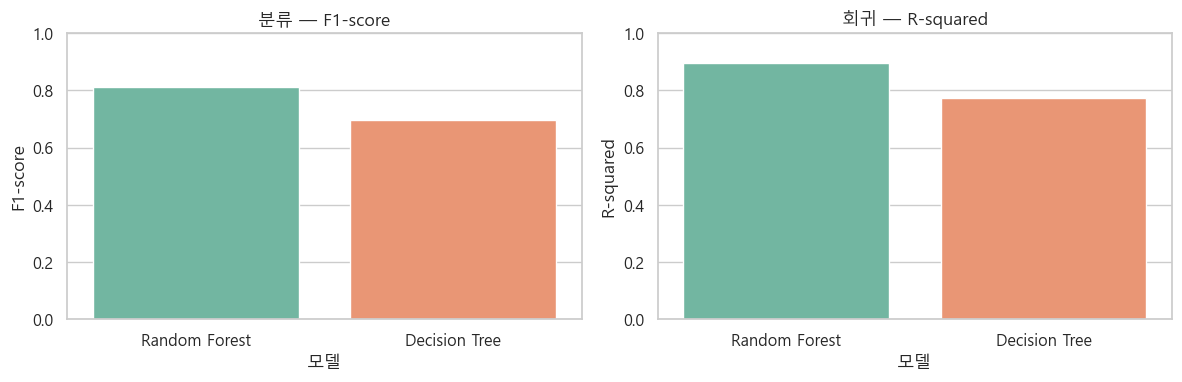


[해석]
- Random Forest는 단일 나무보다 항상 우수한 것은 아니지만, 이번 데이터에서는 분류·회귀 모두 RF가 더 좋은 성능을 보였습니다.
- 단일 나무는 학습 데이터에 과적합하기 쉬워 분산이 큽니다.
- RF는 붓스트랩 샘플링 + 무작위 변수 선택으로 여러 나무의 예측을 결합(다수결/평균)하여
  개별 나무의 오차를 상쇄하고 일반화 성능(분산 감소)을 높입니다.
- 다만 튜닝된 단일 나무가 RF보다 나을 수도 있으므로, '항상 RF가 더 좋다'고 단정할 수는 없습니다.


In [18]:
# [과제 2] 단일 의사결정나무 vs Random Forest 성능 비교
setup_korean_font()

DT_cls = DecisionTreeClassifier(random_state=0)
DT_cls.fit(X_train_cls, Y_train_cls)
DT_cls_pred = DT_cls.predict(X_test_cls)

DT_reg = DecisionTreeRegressor(random_state=0)
DT_reg.fit(X_train_reg, Y_train_reg)
DT_reg_pred = DT_reg.predict(X_test_reg)

cls_model_compare = pd.DataFrame({
    "모델": ["Random Forest", "Decision Tree"],
    "Accuracy": [
        accuracy_score(Y_test_cls, RF_cls_pred),
        accuracy_score(Y_test_cls, DT_cls_pred),
    ],
    "F1-score": [
        f1_score(Y_test_cls, RF_cls_pred),
        f1_score(Y_test_cls, DT_cls_pred),
    ],
})

reg_model_compare = pd.DataFrame({
    "모델": ["Random Forest", "Decision Tree"],
    "R-squared": [
        r2_score(Y_test_reg, RF_reg_pred),
        r2_score(Y_test_reg, DT_reg_pred),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(Y_test_reg, RF_reg_pred)),
        np.sqrt(mean_squared_error(Y_test_reg, DT_reg_pred)),
    ],
})

print("[분류] 모델 비교")
print(cls_model_compare.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n[회귀] 모델 비교")
print(reg_model_compare.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=cls_model_compare, x="모델", y="F1-score", hue="모델", ax=axes[0], legend=False)
axes[0].set_title("분류 — F1-score")
axes[0].set_ylim(0, 1)

sns.barplot(data=reg_model_compare, x="모델", y="R-squared", hue="모델", ax=axes[1], legend=False)
axes[1].set_title("회귀 — R-squared")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\n[해석]")
print("- Random Forest는 단일 나무보다 항상 우수한 것은 아니지만, 이번 데이터에서는 분류·회귀 모두 RF가 더 좋은 성능을 보였습니다.")
print("- 단일 나무는 학습 데이터에 과적합하기 쉬워 분산이 큽니다.")
print("- RF는 붓스트랩 샘플링 + 무작위 변수 선택으로 여러 나무의 예측을 결합(다수결/평균)하여")
print("  개별 나무의 오차를 상쇄하고 일반화 성능(분산 감소)을 높입니다.")
print("- 다만 튜닝된 단일 나무가 RF보다 나을 수도 있으므로, '항상 RF가 더 좋다'고 단정할 수는 없습니다.")

**[과제 3]** 지수는 Random Forest의 성능을 더 높이기 위해 하이퍼파라미터 튜닝을 시도하려고 합니다. 하지만 n_estimators, max_depth, min_samples_split, max_features 등의 의미와 적절한 범위를 잘 모릅니다. AI와 상의하여 각 하이퍼파라미터의 역할을 이해하고 탐색 범위를 직접 설정해 보세요. 이후 GridSearchCV를 활용해 최적의 조합을 찾고, 왜 해당 조합이 선택되었는지 결과를 해석해 보세요.

In [26]:
# [과제 3] 하이퍼파라미터 역할 이해 + GridSearchCV 탐색
# n_estimators  : 나무 개수 (많을수록 안정적이나 학습 시간 증가)
# max_depth     : 트리 최대 깊이 (깊을수록 복잡·과적합 위험)
# min_samples_split : 노드 분할 최소 샘플 수 (크면 단순한 트리)
# max_features  : 노드당 랜덤 선택 변수 비율/개수 (작을수록 트리 다양성 증가)

params_vibe = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", 0.5, 1.0],
}

grid_cls_vibe = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid=params_vibe,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_cls_vibe.fit(X_train_cls, Y_train_cls)

print("최적 파라미터:", grid_cls_vibe.best_params_)
print("CV 최적 F1-score: %.4f" % grid_cls_vibe.best_score_)

best_vibe_pred = grid_cls_vibe.predict(X_test_cls)
print("\n[테스트 성능 — 최적 모델]")
get_classscore(Y_test_cls, best_vibe_pred)

최적 파라미터: {'max_depth': 5, 'max_features': 0.5, 'min_samples_split': 10, 'n_estimators': 200}
CV 최적 F1-score: 0.8141

[테스트 성능 — 최적 모델]
Accuracy  : 0.997
Precision : 0.944
Recall    : 0.773
F1-score  : 0.850

혼동행렬
[[2347    1]
 [   5   17]]



[CV F1-score 상위 5개 조합]
 param_n_estimators param_max_depth  param_min_samples_split param_max_features  mean_test_score
                200               5                       10             0.5000           0.8141
                300               5                       10             0.5000           0.8141
                200              10                       10             0.5000           0.8141
                200            None                       10             0.5000           0.8141
                100               5                        2             0.5000           0.8057


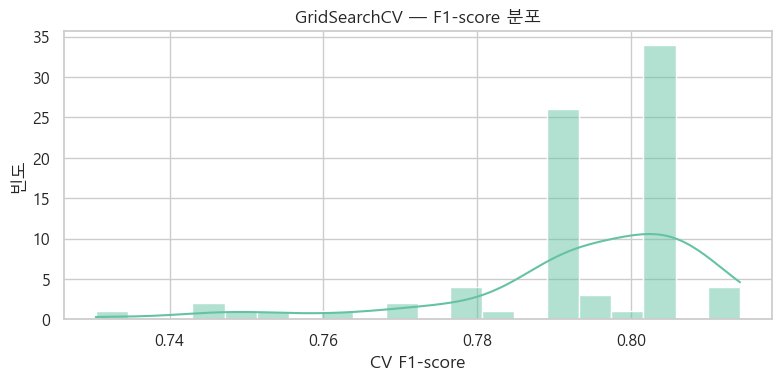


[해석]
- max_depth=5, min_samples_split=10처럼 '얕고 보수적인' 트리가 선택되면 과적합을 줄이는 방향으로 튜닝된 것입니다.
- max_features=0.5는 변수 간 상관을 줄여 트리 다양성을 확보합니다.
- n_estimators=200은 100 대비 성능 이득이 있으면서 300보다 계산 비용이 적은 절충점일 수 있습니다.
- 불균형 분류(Failure=Yes가 소수)에서는 F1 기준 튜닝이 Accuracy만 볼 때보다 실무적으로 타당합니다.


In [24]:
# CV 결과 상위 5개 조합 확인
cv_results = pd.DataFrame(grid_cls_vibe.cv_results_)
top5 = cv_results.nlargest(5, "mean_test_score")[
    ["param_n_estimators", "param_max_depth", "param_min_samples_split",
     "param_max_features", "mean_test_score"]
]
print("\n[CV F1-score 상위 5개 조합]")
print(top5.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

setup_korean_font()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(cv_results["mean_test_score"], bins=20, kde=True, ax=ax)
ax.set_title("GridSearchCV — F1-score 분포")
ax.set_xlabel("CV F1-score")
ax.set_ylabel("빈도")
plt.tight_layout()
plt.show()

print("\n[해석]")
print("- max_depth=5, min_samples_split=10처럼 '얕고 보수적인' 트리가 선택되면 과적합을 줄이는 방향으로 튜닝된 것입니다.")
print("- max_features=0.5는 변수 간 상관을 줄여 트리 다양성을 확보합니다.")
print("- n_estimators=200은 100 대비 성능 이득이 있으면서 300보다 계산 비용이 적은 절충점일 수 있습니다.")
print("- 불균형 분류(Failure=Yes가 소수)에서는 F1 기준 튜닝이 Accuracy만 볼 때보다 실무적으로 타당합니다.")

**[과제 4]**
지수는 Random Forest에서 나무의 개수(n_estimators)를 많이 늘릴수록 성능이 계속 좋아지는지 궁금해졌습니다. AI와 상의하여 다양한 n_estimators 값(예: 10, 50, 100, 200, 500 등)으로 모델을 학습시키고 성능 변화를 그래프로 시각화해 보세요. 성능 향상과 학습 시간의 변화를 함께 확인한 뒤, 실무에서는 어떤 값을 선택하는 것이 적절할지 의견을 정리해 보세요.

 n_estimators  F1-score  Accuracy  학습시간(초)
           10    0.7778    0.9966   0.0866
           50    0.8205    0.9970   0.3687
          100    0.8108    0.9970   0.7891
          200    0.8421    0.9975   1.5312
          500    0.8421    0.9975   4.5961


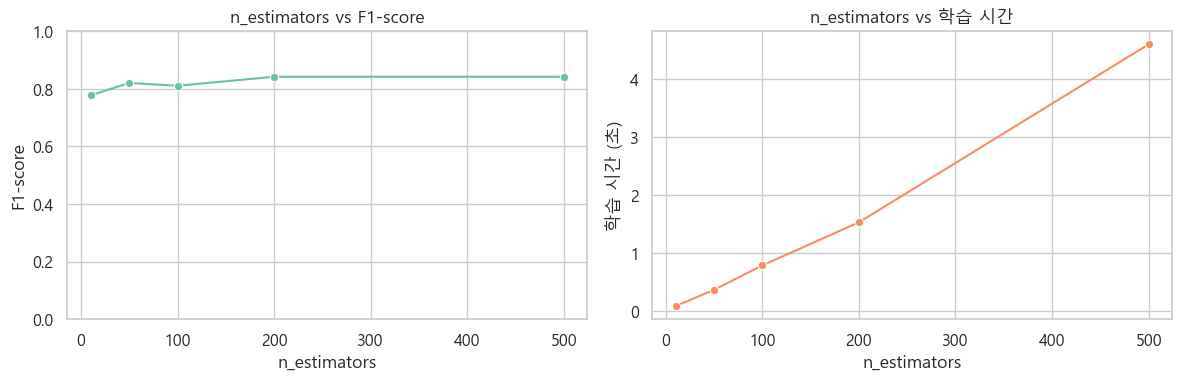


[실무 선택 가이드]
- n_estimators를 늘리면 성능이 monotonic하게 개선되지 않으며, 일정 값(예: 200) 이후에는 성능이 수렴합니다.
- 반면 학습 시간은 거의 선형으로 증가하므로, '성능 향상 대비 비용'을 함께 봐야 합니다.
- 실무에서는 100~300 범위에서 CV로 성능 수렴 지점을 찾고, 배포·재학습 주기·자원 제약을 고려해 결정하는 것이 적절합니다.


In [ ]:
# [과제 4] n_estimators 변화에 따른 성능·학습 시간 분석
import time

setup_korean_font()

n_list = [10, 50, 100, 200, 500]
records = []

for n in n_list:
    model = RandomForestClassifier(n_estimators=n, random_state=0)
    start = time.time()
    model.fit(X_train_cls, Y_train_cls)
    elapsed = time.time() - start
    pred = model.predict(X_test_cls)
    records.append({
        "n_estimators": n,
        "F1-score": f1_score(Y_test_cls, pred),
        "Accuracy": accuracy_score(Y_test_cls, pred),
        "학습시간(초)": elapsed,
    })

n_est_df = pd.DataFrame(records)
print(n_est_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=n_est_df, x="n_estimators", y="F1-score", marker="o", ax=axes[0])
axes[0].set_title("n_estimators vs F1-score")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("F1-score")
axes[0].set_ylim(0, 1)

sns.lineplot(data=n_est_df, x="n_estimators", y="학습시간(초)", marker="o", color="C1", ax=axes[1])
axes[1].set_title("n_estimators vs 학습 시간")
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("학습 시간 (초)")

plt.tight_layout()
plt.show()

print("\n[실무 선택 가이드]")
print("- n_estimators를 늘리면 성능이 monotonic하게 개선되지 않으며, 일정 값(예: 200) 이후에는 성능이 수렴합니다.")
print("- 반면 학습 시간은 거의 선형으로 증가하므로, '성능 향상 대비 비용'을 함께 봐야 합니다.")
print("- 실무에서는 100~300 범위에서 CV로 성능 수렴 지점을 찾고, 배포·재학습 주기·자원 제약을 고려해 결정하는 것이 적절합니다.")